In [1]:
import numpy as np
import pandas as pd
from plotnine import *
import argparse
import re
import sys
import gzip


parser = argparse.ArgumentParser()
parser.add_argument('--genes', '-g', help='genes bed file')
parser.add_argument('--depths', '-d', help='per gene read counts')
parser.add_argument('--megs', '-m', help='total bam read counts')
parser.add_argument('--readlength', '-l', help='read length',default=150)

args = parser.parse_args()
genes = args.genes
depths = args.depths
megs = args.megs
readlen = args.readlength




In [2]:
genefile = "./resources/VectorBase-59_AaegyptiLVP_AGWG_gene_regions_refseq.bed"
depthfile = "./all_gene_covs.txt.gz"
megfile = "./all_bam_mbs.txt.gz"
readlength = 150

In [3]:
depths = np.genfromtxt(depthfile,skip_header=1,dtype=int,delimiter='\t')
samples = gzip.open(depthfile,'r').readline().strip().split()
samples = [s.decode() for s in samples]

In [4]:
megs = np.recfromtxt(megfile,names=['sample','mapped','unmapped'])
mb = (megs['mapped'] * readlength) / 1e6
genes = np.recfromtxt(genefile,names=['chrom','start','end','name','score','strand'],encoding=None)
kb = (genes['end']-genes['start'])/1e3


/opt/miniconda3/lib/python3.9/site-packages/numpy/lib/npyio.py:2371: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.


In [5]:
rpk = depths.astype(int).transpose() / kb
rpkm = rpk.transpose() / mb

In [6]:
kbdp = pd.DataFrame(data={'kb': kb, 'meandp': np.mean(depths,1), 'meanrpk': np.mean(rpkm,1)})

In [7]:
rpkmtab = pd.DataFrame(data={'gene': genes['name'], 'kb': kb, 
                             'sdrpkm': np.std(rpkm,1), 
                             'meanrpkm': np.mean(rpkm,1)})

rpkmnorm = rpkm/np.mean(rpkm)
rpkmnormtab = pd.DataFrame(data={'gene': genes['name'], 'kb': kb, 
                                 'sdrpkm': np.std(rpkmnorm,1), 
                                 'meanrpkm': np.mean(rpkmnorm,1)})

In [8]:
#get gste / p450 target genes from table
targetgenes = pd.read_table("gste_p450_annotations.txt",delimiter="\t",dtype=None,encoding=None)
targetgenenames =  [g for g in genes['name'] if g in targetgenes['geneid'].tolist()]

In [10]:
#get gste / p450 target genes from table
targetgenes = pd.read_table("gste_p450_annotations.txt",delimiter="\t",dtype=None,encoding=None)
targetgenes['genename'] = [re.sub('\_.*|\ .*','',a) for a in targetgenes['blastp']]
targetgenenames =  [g for g in genes['name'] if g in targetgenes['geneid'].tolist()]


/opt/miniconda3/lib/python3.9/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 104 rows containing missing values.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 6 x 6 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_volcano.png
/opt/miniconda3/lib/python3.9/site-packages/plotnine/layer.py:401: PlotnineWarning: geom_point : Removed 104 rows containing missing values.


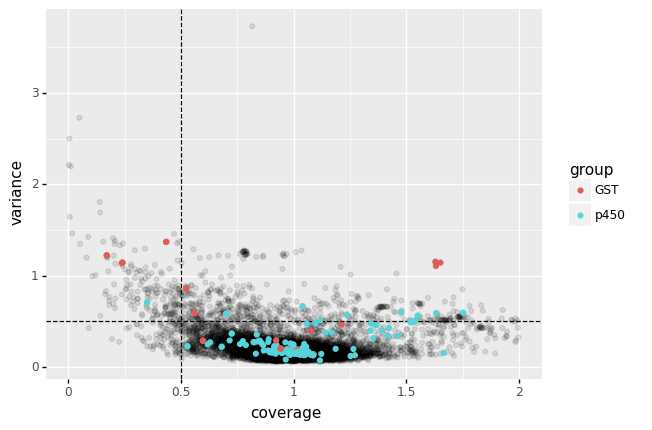

In [28]:
rpkmnormgstes = rpkmnormtab.merge(targetgenes,left_on="gene",right_on="geneid")
volcp = ggplot(rpkmnormtab, aes('meanrpkm', 'sdrpkm/meanrpkm'))  + \
    geom_hline(yintercept=0.5,linetype="dashed") + geom_vline(xintercept=0.5,linetype="dashed") +\
    geom_point(alpha=0.1) +\
    geom_point(data=rpkmnormgstes,mapping=aes(color="group")) +\
    xlim(0,2) + xlab("coverage") + ylab("variance")

volcp.draw()
volcp.save("rpkm_volcano.png",width=6,height=6)



In [12]:
vargenes = rpkmnormtab['gene'][(rpkmnormtab['sdrpkm']/rpkmnormtab['meanrpkm']) > 0.5].tolist()

#vargenes = rpkmnormtab['gene'][np.logical_and((rpkmnormtab['sdrpkm']/rpkmnormtab['meanrpkm']) > 0.5,
#                                              (rpkmnormtab['meanrpkm'] > 0.25))]

vargenesgste = [v for v in vargenes if v in targetgenenames]
vargenesother = [v for v in vargenes if v not in targetgenenames]

In [13]:
len(vargenes),len(vargenesgste),len(vargenesother),

(754, 18, 736)

In [14]:
meta = pd.read_table("resources/meta_Aaeg1kg_spp.txt")


In [15]:
select = np.concatenate((vargenesgste, np.random.choice(vargenesother,10)))

selectidx = [g in select for g in genes['name'].tolist()]
#get target genes only from ndarray, make data frame
tgtrpkmnorm = pd.DataFrame(rpkmnorm[selectidx])
tgtrpkmnorm.index = select
tgtrpkmnorm.columns = samples
tgtrpkmnorm['gene'] = select
tgtrpkmnorm = pd.melt(tgtrpkmnorm,var_name="sample",id_vars=['gene'])
tgtrpkmnorm = tgtrpkmnorm.merge(meta)
tgtrpkmnorm = tgtrpkmnorm.merge(targetgenes,left_on='gene',right_on='geneid',how="outer")

In [16]:
#limit to big countries only
bigcountries = meta.groupby('country').filter(lambda x: len(x) >= 20)['country'].unique()

tgtrpkmnorm = tgtrpkmnorm.loc[[c in bigcountries for c in tgtrpkmnorm['country']]]
#sort by est demographic history
tgtrpkmnorm['country'] = pd.Categorical(tgtrpkmnorm['country'], ['Kenya', 'Uganda', 
                                                                 'Gabon', 'Ghana', 'BurkinaFaso','Senegal', 
                                                                 'PuertoRico', 'Trinidad', 
                                                                 'Brazil', 'USA', 
                                                                 'SaudiArabia', 'Vietnam','Philippines'])

In [17]:
tgtrpkmnorm_450 = tgtrpkmnorm[tgtrpkmnorm['group']=='p450']
tgtrpkmnorm_gst = tgtrpkmnorm[tgtrpkmnorm['group']=='GST']
tgtrpkmnorm_rnd = tgtrpkmnorm[tgtrpkmnorm['group'].isnull()]

In [19]:
print("c450",tgtrpkmnorm_450['genename'].unique())
print("GSTe",tgtrpkmnorm_gst['genename'].unique())

c450 ['CYP6M9' 'CYP9M6' 'CYP325S1' 'CYP9J17' 'CYP9J10' 'CYP9J22' 'CYP9J23'
 'CYP9J24' 'CYP9J26' 'CYP9J29']
GSTe ['AAEL015285-PB' 'AAEL015285-PA' 'GSTE4' 'GSTE7' 'GSTE2' 'GSTE5' 'GSTE6'
 'GSTE3' 'microsomal']


In [20]:
ylim=[0,15]

/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 10 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_p450_box.png


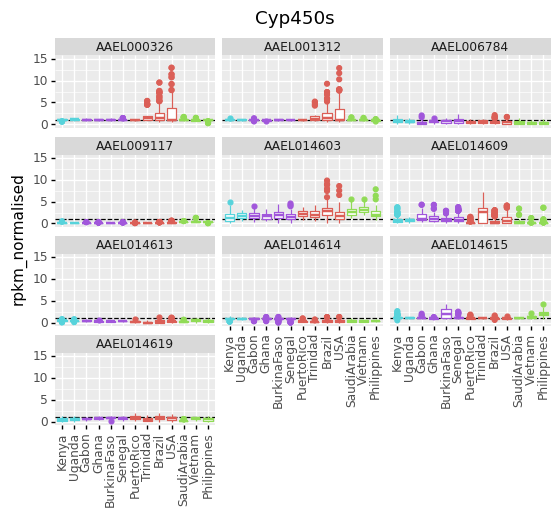

In [21]:
p450P = ggplot(tgtrpkmnorm_450, aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('gene',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("Cyp450s") +\
    coord_cartesian(ylim=ylim)
p450P.draw()
p450P.save("rpkm_p450_box.png",width=15,height=10)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 10 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_p450_name_box.png


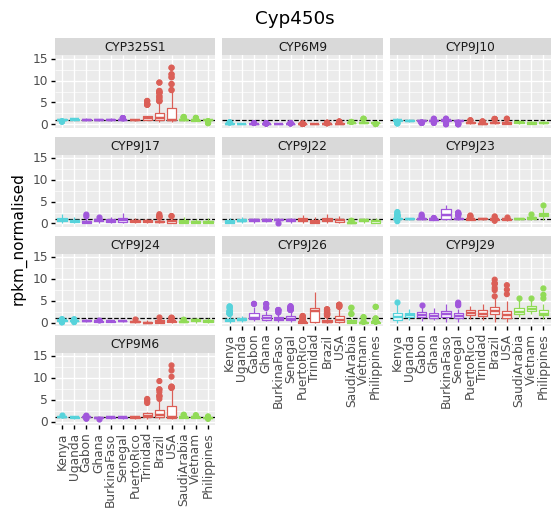

In [22]:
p450P = ggplot(tgtrpkmnorm_450, aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("Cyp450s") +\
    coord_cartesian(ylim=ylim)
p450P.draw()
p450P.save("rpkm_p450_name_box.png",width=15,height=10)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 10 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_gstes_box.png


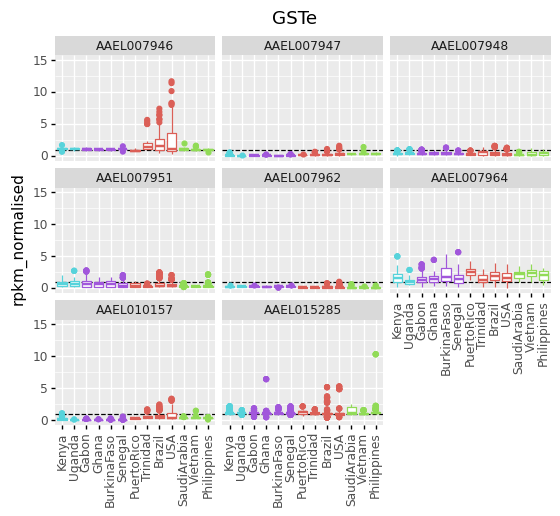

In [23]:
gstesP = ggplot(tgtrpkmnorm_gst, aes('country', 'value',color='contgroup',group='country')) +  \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('gene',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("GSTe") +\
    coord_cartesian(ylim=ylim)
gstesP.draw()
gstesP.save("rpkm_gstes_box.png",width=15,height=10)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 10 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_gstes_name_box.png


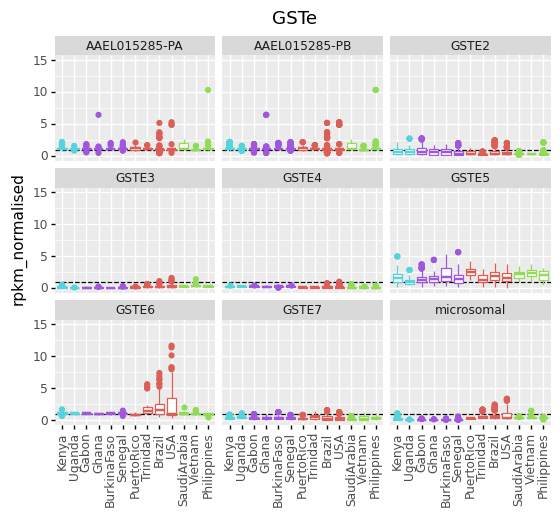

In [24]:
gstesP = ggplot(tgtrpkmnorm_gst, aes('country', 'value',color='contgroup',group='country')) +  \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("GSTe") +\
    coord_cartesian(ylim=ylim)
gstesP.draw()
gstesP.save("rpkm_gstes_name_box.png",width=15,height=10)


In [ ]:
i=1
rndP = ggplot(tgtrpkmnorm_rnd, aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('gene',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("random {}".format(i)) +\
    coord_cartesian(ylim=ylim)
rndP.draw()
rndP.save("rpkm_rnd_{}_box.png".format(i),width=15,height=10)


/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 4 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_gstes_select_box.png
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 4 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_p450_select_box.png


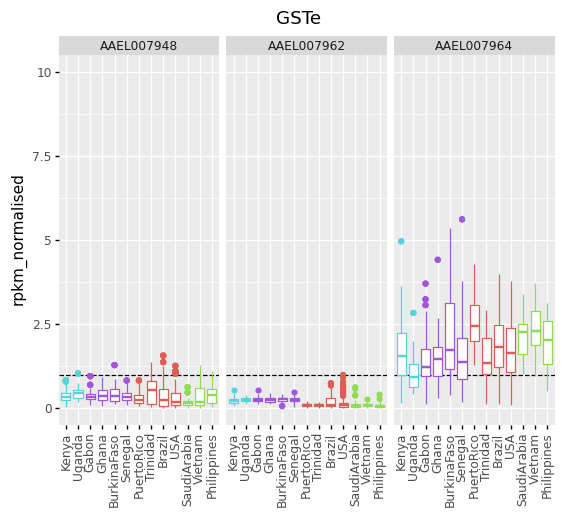

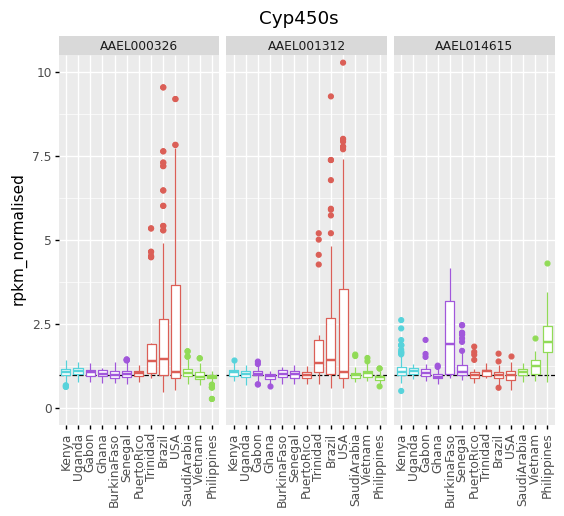

In [26]:
selects = ["AAEL000326", "AAEL001312", "AAEL014615",
           "AAEL007948","AAEL007964","AAEL007962",
          "AAEL005123","AAEL023980","AAEL022583"]

# AAEL000326 -> 3:112mb
# AAEL001312 -> 2:447mb

ylim=[0,10]
gstesPk = ggplot(tgtrpkmnorm_gst[tgtrpkmnorm_gst['geneid'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) +  \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('gene',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("GSTe") +\
    coord_cartesian(ylim=ylim)
gstesPk.draw()
gstesPk.save("rpkm_gstes_select_box.png",width=15,height=4)

p450Pk = ggplot(tgtrpkmnorm_450[tgtrpkmnorm_450['geneid'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('gene',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("Cyp450s") +\
    coord_cartesian(ylim=ylim)
p450Pk.draw()
p450Pk.save("rpkm_p450_select_box.png",width=15,height=4)


#rndPk = ggplot(tgtrpkmnorm_rnd[tgtrpkmnorm_rnd['gene'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) + \
#    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('gene',ncol=3) + \
#    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
#    ylab("rpkm_normalised") + ggtitle("random") +\
#    coord_cartesian(ylim=ylim)
#rndPk.draw()
#rndPk.save("rpkm_rnd_select_box.png",width=15,height=4)




/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 4 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_gstes_select_name_box.png
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Saving 15 x 4 in image.
/opt/miniconda3/lib/python3.9/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: rpkm_p450_select_name_box.png


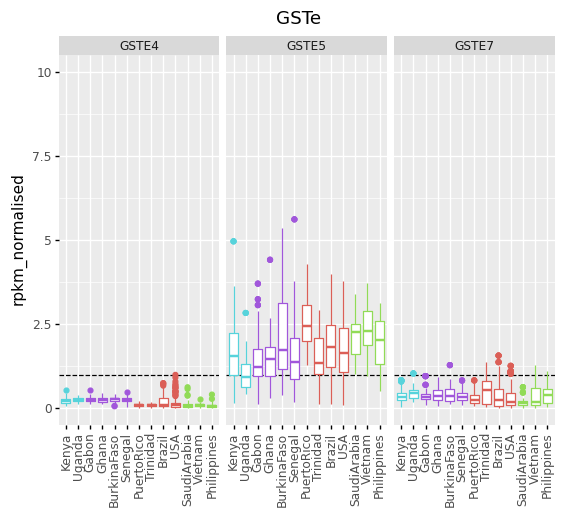

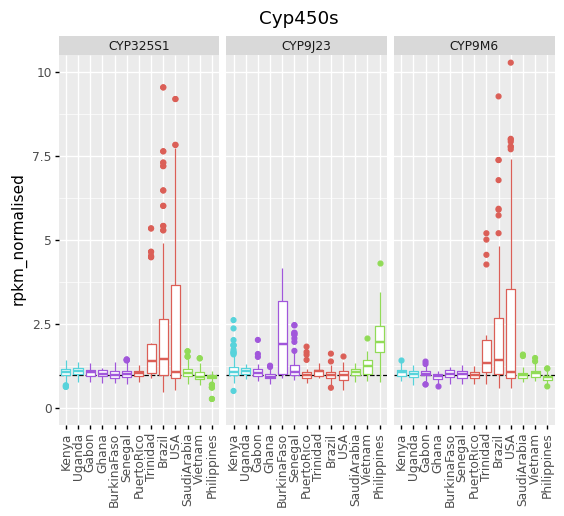

In [27]:
ylim=[0,10]
gstesPk = ggplot(tgtrpkmnorm_gst[tgtrpkmnorm_gst['geneid'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) +  \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("GSTe") +\
    coord_cartesian(ylim=ylim)
gstesPk.draw()
gstesPk.save("rpkm_gstes_select_name_box.png",width=15,height=4)

p450Pk = ggplot(tgtrpkmnorm_450[tgtrpkmnorm_450['geneid'].isin(selects)], aes('country', 'value',color='contgroup',group='country')) + \
    geom_hline(yintercept=1,linetype="dashed") + geom_boxplot() + facet_wrap('genename',ncol=3) + \
    theme(axis_text_x=element_text(angle=90),axis_title_x=element_blank(),legend_position="none") +\
    ylab("rpkm_normalised") + ggtitle("Cyp450s") +\
    coord_cartesian(ylim=ylim)
p450Pk.draw()
p450Pk.save("rpkm_p450_select_name_box.png",width=15,height=4)